# Compare 2 WindFarmer API JSON input files

In [8]:
import os
import json
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd

In [2]:
input_file1 = 'BalticCoast_4D 160 degrees x 8D 250 degrees.json'
input_file2 = 'TheBowl.json'

In [3]:
with open(input_file1, 'r') as file1:
    input_data_1 = json.load(file1)
with open(input_file2, 'r') as file2:
    input_data_2 = json.load(file2)

## Compare wind climates

<Axes: title={'center': 'FINO_2 150m Overall frequency by wind speed'}>

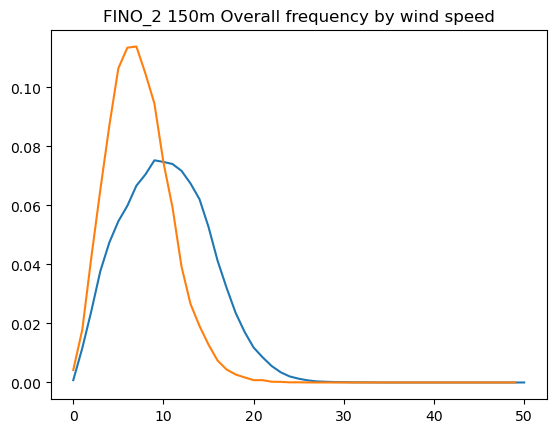

In [21]:
wind_climate_name_1 = "FINO_2 150m"
wind_climate_name_2 = "M1 98m"

def get_fd_as_dataframe(input_data_json, wind_climate_name):
    wind_climate = next(iter( x for x in input_data_json["windClimates"] if x["id"] == wind_climate_name))
    freq_dist_df = pd.DataFrame(wind_climate["probabilityDistribution"]).T
    freq_dist_df.index = wind_climate["windSpeedBinUpperLimits_m_per_s"] 
    freq_dist_df.index = freq_dist_df.index - 0.5
    freq_dist_df["overall"] = freq_dist_df.sum(axis=1)
    return freq_dist_df

freq_dist_1_df = get_fd_as_dataframe(input_data_1, wind_climate_name_1)
freq_dist_2_df = get_fd_as_dataframe(input_data_2, wind_climate_name_2)

freq_dist_1_df["overall"].plot(title=wind_climate_name_1 + " Overall frequency by wind speed",)
freq_dist_2_df["overall"].plot(title=wind_climate_name_1 + " Overall frequency by wind speed",)

